In [1]:
%pip install -q joblib scikit-learn pandas matplotlib numpy


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

ruta = Path("..")
datos = pd.read_csv(ruta / "data" / "samsung.csv")
datos["Date"] = pd.to_datetime(datos["Date"], format="%d/%m/%Y")
datos = datos.sort_values("Date").reset_index(drop=True)
datos.head()

,Date,Close,Volume
0,2008-01-02,10880,18047200
1,2008-01-03,10920,19346500
2,2008-01-04,10780,17997350
3,2008-01-07,10380,39787200
4,2008-01-08,10320,24783700


In [3]:
print("Dimensiones:", datos.shape)
print("Rango de fechas:", datos["Date"].min(), "a", datos["Date"].max())
print("Valores nulos:", datos.isna().sum().sum())
datos[["Close", "Volume"]].describe()

Dimensiones: (2850, 3)
Rango de fechas: 2008-01-02 00:00:00 a 2019-06-28 00:00:00
Valores nulos: 0


,Close,Volume
count,2850.000000,2.850000e+03
mean,26611.305263,1.610505e+07
std,11991.608543,8.661794e+06
min,8040.000000,0.000000e+00
25%,16300.000000,1.021426e+07
50%,25600.000000,1.359033e+07
75%,30850.000000,1.960970e+07
max,57220.000000,6.487345e+07


In [4]:
volumen_valido = datos["Volume"].replace(0, np.nan)
datos["retorno"] = datos["Close"].pct_change()
datos["volatilidad_5d"] = datos["retorno"].rolling(5).std()
datos["cambio_volumen"] = np.log(volumen_valido / volumen_valido.shift(1))
datos["media_movil_10d"] = datos["Close"].rolling(10).mean()
datos["desviacion_media_movil"] = (datos["Close"] - datos["media_movil_10d"]) / datos["media_movil_10d"]

datos = datos.replace([np.inf, -np.inf], np.nan)
datos_features = datos.dropna().reset_index(drop=True)
columnas_features = ["retorno", "volatilidad_5d", "cambio_volumen", "desviacion_media_movil"]
print("Filas utilizables tras ingenieria de variables:", len(datos_features))
datos_features[columnas_features].describe()

Filas utilizables tras ingenieria de variables: 2815


,retorno,volatilidad_5d,cambio_volumen,desviacion_media_movil
count,2815.000000,2815.000000,2815.000000,2815.000000
mean,0.000734,0.017162,-0.000767,0.002500
std,0.018920,0.008696,0.415311,0.028757
min,-0.149206,0.001750,-6.988612,-0.205298
25%,-0.010208,0.011370,-0.234118,-0.016143
50%,0.000000,0.015692,-0.016889,0.002269
75%,0.011122,0.021081,0.231384,0.021417
max,0.130526,0.107920,7.562282,0.114894


In [5]:
BLUE = "#2a78d6"
ORANGE = "#eb6834"
AQUA = "#1baf7a"
YELLOW = "#eda100"
MUTED = "#898781"
GRID = "#e1e0d9"
SURFACE = "#fcfcfb"
PALETA = [BLUE, ORANGE, AQUA, YELLOW]

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
})

x = datos_features[columnas_features].values
escalador = StandardScaler()
x_escalado = escalador.fit_transform(x)

In [6]:
valores_k = range(2, 9)
inercias = []
siluetas = []

for k in valores_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = km.fit_predict(x_escalado)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(x_escalado, etiquetas))

busqueda_k = pd.DataFrame({"k": list(valores_k), "inercia": inercias, "silueta": siluetas})
busqueda_k.to_csv(ruta / "results" / "kmeans_busqueda_k.csv", index=False)
busqueda_k

,k,inercia,silueta
0,2,8765.632458,0.223451
1,3,7313.360315,0.233750
2,4,6460.512573,0.228693
3,5,5888.276012,0.196385
4,6,5423.584922,0.196832
5,7,5059.588282,0.190441
6,8,4745.720999,0.190093


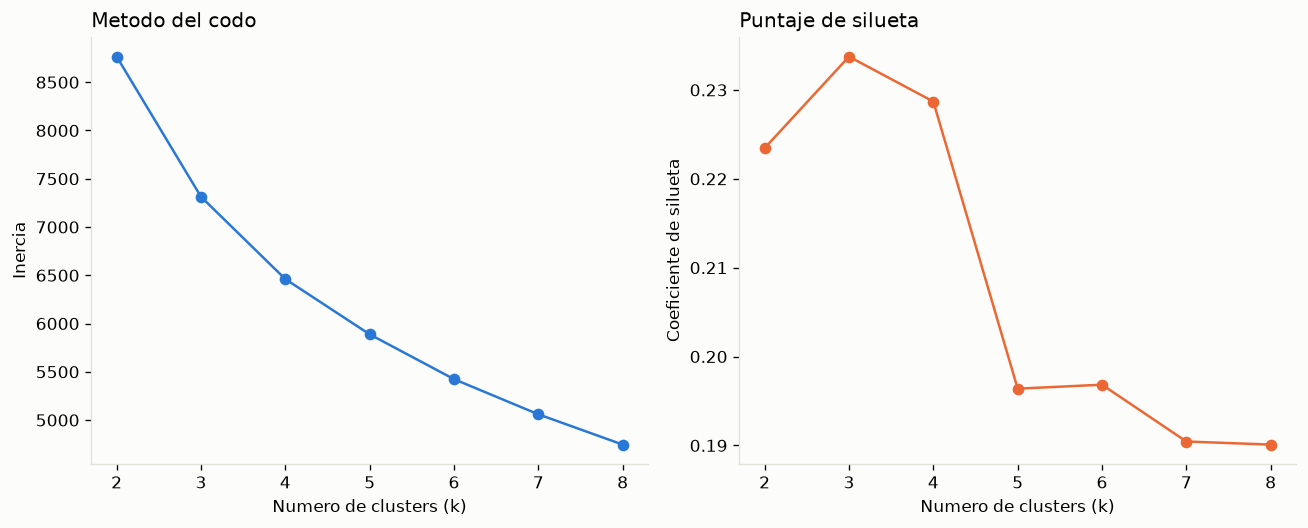

k optimo segun silueta: 3


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5), dpi=120)

ax1.plot(busqueda_k["k"], busqueda_k["inercia"], marker="o", color=BLUE)
ax1.set_xlabel("Numero de clusters (k)")
ax1.set_ylabel("Inercia")
ax1.set_title("Metodo del codo", loc="left")

ax2.plot(busqueda_k["k"], busqueda_k["silueta"], marker="o", color=ORANGE)
ax2.set_xlabel("Numero de clusters (k)")
ax2.set_ylabel("Coeficiente de silueta")
ax2.set_title("Puntaje de silueta", loc="left")

fig.tight_layout()
fig.savefig(ruta / "figures" / "sa_kmeans_optimizacion.png", facecolor=SURFACE)
plt.show()

k_optimo = int(busqueda_k.loc[busqueda_k["silueta"].idxmax(), "k"])
print("k optimo segun silueta:", k_optimo)

In [8]:
modelo_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
datos_features["cluster"] = modelo_final.fit_predict(x_escalado)
silueta_final = silhouette_score(x_escalado, datos_features["cluster"])
print(f"Modelo final: k={k_optimo} | Silueta = {silueta_final:.3f}")
datos_features.groupby("cluster")[columnas_features].mean().round(4)

Modelo final: k=3 | Silueta = 0.234


,retorno,volatilidad_5d,cambio_volumen,desviacion_media_movil
cluster,,,,
0,-0.0196,0.0193,0.2016,-0.0255
1,0.0232,0.0239,0.1960,0.0292
2,0.0016,0.0137,-0.1646,0.0053


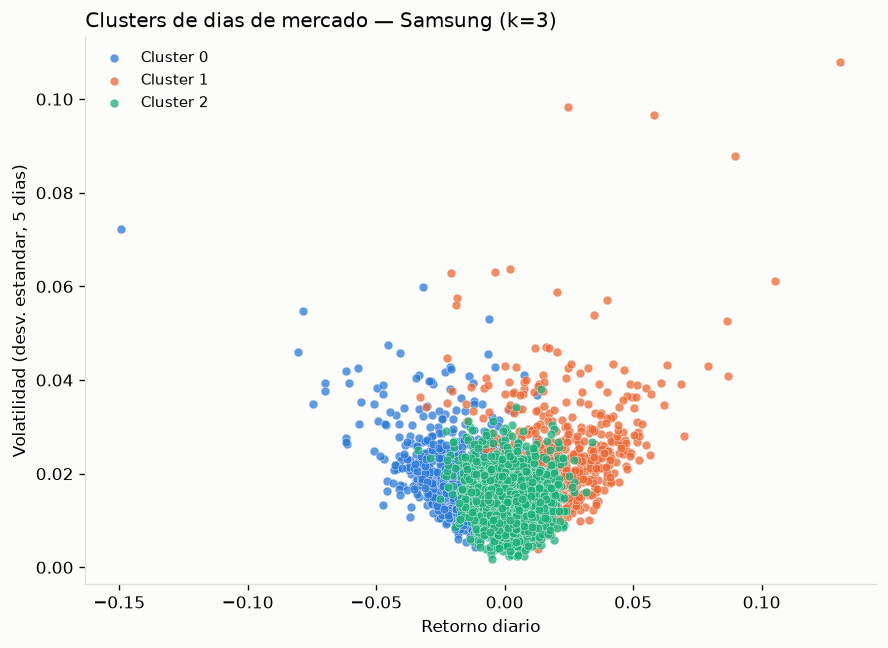

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 5.5), dpi=120)
for c in range(k_optimo):
    subset = datos_features[datos_features["cluster"] == c]
    ax.scatter(subset["retorno"], subset["volatilidad_5d"], s=28, alpha=0.75,
               color=PALETA[c % len(PALETA)], label=f"Cluster {c}", edgecolor="white", linewidth=0.3)
ax.set_xlabel("Retorno diario")
ax.set_ylabel("Volatilidad (desv. estandar, 5 dias)")
ax.set_title(f"Clusters de dias de mercado — Samsung (k={k_optimo})", loc="left")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(ruta / "figures" / "sa_kmeans_clusters.png", facecolor=SURFACE)
plt.show()

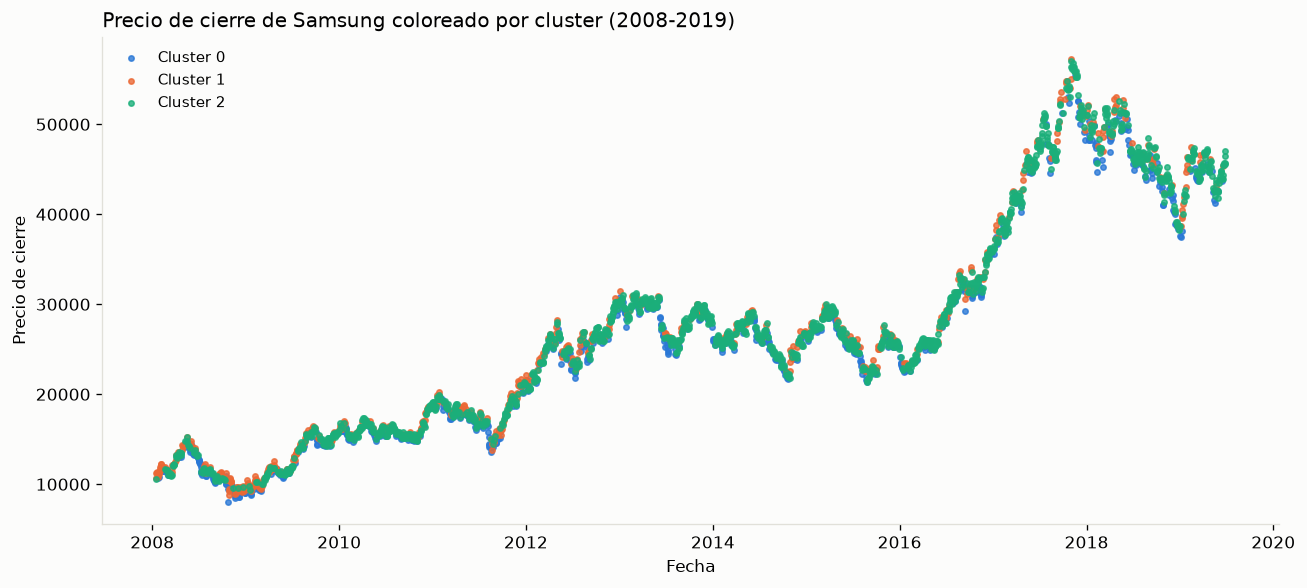

In [10]:
fig, ax = plt.subplots(figsize=(11, 5), dpi=120)
for c in range(k_optimo):
    subset = datos_features[datos_features["cluster"] == c]
    ax.scatter(subset["Date"], subset["Close"], s=10, alpha=0.8,
               color=PALETA[c % len(PALETA)], label=f"Cluster {c}")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio de cierre")
ax.set_title("Precio de cierre de Samsung coloreado por cluster (2008-2019)", loc="left")
ax.legend(frameon=False, fontsize=9, loc="upper left")
fig.tight_layout()
fig.savefig(ruta / "figures" / "sa_kmeans_serie_tiempo.png", facecolor=SURFACE)
plt.show()

In [11]:
joblib.dump(
    {"modelo": modelo_final, "escalador": escalador, "columnas": columnas_features},
    ruta / "models" / "sa_kmeans_samsung.joblib"
)
print("Modelo guardado en la carpeta models/")

Modelo guardado en la carpeta models/
